In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP 1 /data para colab')

Mounted at /content/drive


In [ ]:
cant_archivos = len(os.listdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP 1 /data para colab'))-3 #cuento los archivos y le resto el excel y los dos raros
print(cant_archivos)

posicion =[]
respuesta = []
tiempo = []

for i in range(1, cant_archivos):
    nombre_archivo = f'data_{i}.csv'     #loop que lee los archivos data_i
    df = pd.read_csv(nombre_archivo)

    posicion = list(posicion) + list(df.iloc[:, 3])
    respuesta = list(respuesta) + list(df.iloc[:, 4])#armo listas que contienen TODAS las respuestas de todos los archivos
    tiempo = list(tiempo) + list(df.iloc[:, 5])

print(posicion)
print(respuesta)
print(tiempo)
print(len(respuesta), len(respuesta), len(tiempo))

rtas_corr = np.array([0]*7) #vector de cantidad de rtas correctas

for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            rtas_corr[posicion[j]-1] += 1 #al vector de rtas correctas le sumo uno en la posicion de la letra
print(rtas_corr)

20
[1, 1, 7, 2, 5, 1, 7, 1, 1, 1, 7, 1, 6, 6, 5, 1, 5, 1, 1, 1, 2, 1, 6, 3, 2, 4, 4, 4, 3, 3, 4, 1, 6, 5, 7, 1, 3, 3, 6, 6, 6, 5, 5, 2, 2, 6, 4, 6, 6, 6, 2, 7, 6, 7, 3, 6, 4, 6, 1, 6, 1, 2, 5, 6, 7, 5, 5, 6, 1, 4, 3, 4, 5, 5, 2, 5, 1, 5, 5, 3, 5, 7, 5, 5, 4, 7, 6, 5, 2, 3, 6, 3, 1, 3, 5, 2, 6, 4, 2, 3, 5, 4, 5, 5, 5, 7, 1, 5, 5, 7, 5, 2, 5, 5, 1, 7, 6, 5, 4, 5, 7, 2, 4, 2, 7, 2, 4, 1, 3, 2, 1, 2, 2, 6, 2, 2, 3, 2, 5, 6, 2, 5, 4, 5, 1, 2, 3, 7, 2, 6, 1, 4, 7, 4, 5, 4, 6, 4, 7, 6, 6, 5, 2, 1, 2, 4, 4, 3, 4, 4, 4, 4, 5, 1, 2, 4, 4, 3, 3, 7, 4, 3, 4, 4, 4, 1, 6, 5, 1, 6, 7, 7, 1, 2, 4, 2, 4, 6, 2, 4, 4, 5, 4, 4, 5, 4, 3, 3, 4, 7, 5, 2, 1, 4, 3, 6, 6, 6, 4, 2, 6, 6, 7, 6, 6, 4, 6, 6, 7, 5, 6, 2, 3, 6, 6, 5, 1, 3, 1, 7, 5, 6, 4, 4, 2, 3, 3, 1, 6, 2, 4, 4, 4, 4, 4, 4, 1, 7, 5, 4, 1, 7, 4, 4, 4, 7, 3, 6, 2, 5, 3, 4, 7, 6, 2, 5, 1, 6, 3, 3, 4, 3, 1, 3, 5, 5, 3, 3, 4, 6, 7, 3, 3, 2, 2, 3, 3, 7, 3, 1, 5, 3, 2, 3, 3, 3, 3, 6, 2, 6, 7, 3, 5, 4, 6, 2, 4, 3, 5, 3, 1, 3, 7, 1, 7, 3, 4, 1, 3, 3, 7, 7, 

In [ ]:
#quiero encontrar, para cada posicion, el promedio de respuestas correctas en CADA archivo por separado. Con su error

#en cada archivo (loop de i)
    #clasifico en posiciones
        #por pos:
        #veo el promedio
        #veo el error
#promedio los promedios de todos los archivos

posiciones_suma = np.array([0]*7) #genero arrays que quedan fuera de la lectura de cada archivo porque voy a poner el rtado tot
desvest_sumaal2 = np.array([0]*7)

for i in range(1, cant_archivos):
    nombre_archivo = f'data_{i}.csv'     #loop que lee cada archivo data_i por vez
    df = pd.read_csv(nombre_archivo)

    posicion_i = list(df.iloc[:, 3])
    respuesta_i = list(df.iloc[:, 4])    #cada vez que cambie de i vuelve a leer las columnas 3 y 4
    #print(posicion_i)
    #print(respuesta_i)

    rtas_corr_i = np.array([0]*7) #en cada archivo cada vez que cambie de i vuelve a hacer la lista
    for j in range(30):
        if  respuesta_i[j] == 1: #si reponde bien que agregue un uno en la posicion correspondiente al array de rtas corr del archivo i
            rtas_corr_i[posicion_i[j]-1] += 1
    #print(rtas_corr_i)
    #dsp del ultimo paso ya tengo el array rtas_corr_i que tiene la cantidad de rtas correctas por posicion del archivo i.

    #saco el promedio de rtas correctas por posicion del archivo i
    promedio_i = (rtas_corr_i/3)
    #print(promedio_i)
    posiciones_suma = posiciones_suma + promedio_i #despues voy a promediar los promedios de todos los archivos y pasarlo a porcentaje entonces aca los voy sumando y a lo ultimo voy a dividir por cant_archivos

    devest_i = [] #ahora voy a sacar las desvest por pos de cada archivo i
    for p in range (len(rtas_corr_i)):
        if rtas_corr_i[p] == 0 or rtas_corr_i[p] == 3: #como solo son 3 rtas la desv es 0 si las tres son iguales o 0.15 si hay dos iguales (esta en un bloque abajo) nentonces si en la pos p hay 0 o 3 rtas corr le pido que agregue 0 y sino 0.15
            devest_i.append(0)
        else:
            devest_i.append(0.15713484026367722)
        #print('y',devest_i)
    devest_i = np.array(devest_i)
    desvest_sumaal2 = desvest_sumaal2 + devest_i**2 #si tienes errores diferentes para cada dato, la fórmula para el error del promedio es:la raiz de la suma de todas las desv est al cuadrado de cada dato, todo dividido n.

#ya afuera de todos los loops termino de calcular el prom y los errores
#print(posiciones_suma)
porcentajes_prom = (posiciones_suma/cant_archivos)*100
print(porcentajes_prom)
#print('x',desvest_sumaal2)
desvest_prom = np.sqrt(desvest_sumaal2)/cant_archivos*100 #no estoy muy segura de que vaya aca el 100
print(desvest_prom)

[83.33333333 70.         75.         70.         81.66666667 76.66666667
 81.66666667]
[1.9245009  2.60578653 2.22222222 2.72165527 1.75682092 2.3570226
 1.9245009 ]


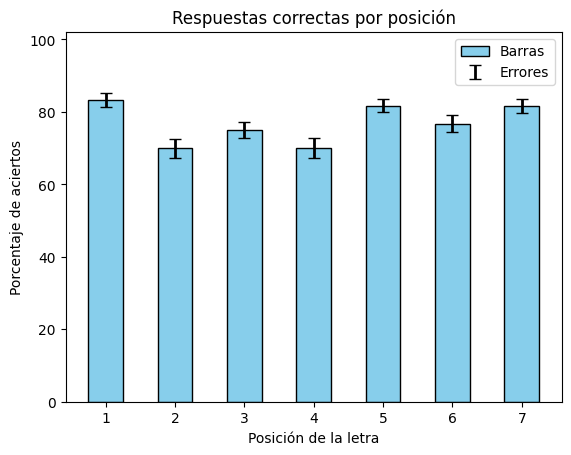

In [ ]:
#ploteo
x = np.array(range(1,8)) #ploteo posiciones #plotear el promedio de los porcentajes de cada persona

plt.bar(x, porcentajes_prom, width = 0.5, color='skyblue', edgecolor='black', label='Barras') #gráfico de barras
plt.errorbar(x, porcentajes_prom, yerr=desvest_prom, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xlabel('Posición de la letra')
plt.ylabel('Porcentaje de aciertos')
plt.ylim(0,102)
plt.title('Respuestas correctas por posición')
plt.show()


correccion de Luz: tenemos que "correr al cero" ("normalizar") las respuestas de cada archivo tomando los tiempos y restandoles la media de cada archivo y dividiensolo por la desviacion estandar.

Despues tenemos que hacer la misma correccion que con los porcentajes de promediar el tiempo de rta por posicion por persona y para el ploteo usar el promedio de esos promedios.

para la cant de archivos uso indice i
para 30 j
para 7 k

In [ ]:
#corro al cero los tiempos de cada archivo i
tiempos_en0 = []

for i in range(1, cant_archivos):
    nombre_archivo = f'data_{i}.csv'     #loop que lee cada archivo data_i por vez
    df = pd.read_csv(nombre_archivo)
    tiempo_i = list(df.iloc[:, 5])
    #print(tiempo_i)
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    #print(promedio_i)
    for j in range(30):
        tiempos_en0.append((tiempo_i[j]-promedio_i)/desvest_i)
print(tiempos_en0)
print(posicion)
print(len(tiempo),len(tiempos_en0)) #tienen que tener el mismo largo

[0.8426668704003257, 0.39870430852652694, 4.1272849967216425, -0.3575136394822465, -0.06111344711486785, -0.5045629145329402, -0.014062339888110889, -0.5100189768493065, -0.6484902680119647, -0.4748179812567028, 0.2296410771761472, -0.20786117969613116, -0.04384679744307574, -0.6951539845493289, -0.32239732700239854, 0.15353968632526804, -0.8536865590587247, -0.4785280322408759, 0.17804424365268287, 0.6443660058241726, -0.8660670431775644, 1.1341395648565797, 1.153065134508015, -0.04981307844683538, -1.1076519825591238, -0.37887799977701164, 1.2582958536278621, -0.9105772467646458, -0.4985207608202329, -1.1361861829471311, -0.47347817086407434, -0.06026861244410988, -0.4355836365459279, 0.6182413925654885, 0.000276952673481986, -0.2541960383108621, -0.4735670421160336, -0.3977952442640516, 1.3494935111169752, -0.32784985320263454, -0.48549947370040797, 0.03304664190122278, -0.09894219364501065, -0.42016299057821094, -0.17433151230927993, -0.37687550703312983, -0.5470770864065176, -0.47

In [ ]:
prom_t_tot = []
err_t_tot = []

prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7 = [],[],[],[],[],[],[] #promedio de las 3 rtas en cada posicion. prom3_k
dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7 = [],[],[],[],[],[],[] #dsv3_k

for i in range(1, cant_archivos): #leo cada archivo y nombro sus columnas
    nombre_archivo = f'data_{i}.csv'
    df = pd.read_csv(nombre_archivo)
    posicion_i = list(df.iloc[:, 3])
    respuesta_i = list(df.iloc[:, 4])
    tiempo_i = list(df.iloc[:, 5])

    tiempo_en0_i = [] #normalizo los tiempos
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    for j in range(30):
        tiempo_en0_i.append((tiempo_i[j]-promedio_i)/desvest_i)
    #print(tiempo_en0_i)
    #print("Datos contienen NaNs:", np.any(np.isnan(tiempo_en0_i)))

    for k in range (1, 7+1):
        t3_i_k = [] #lista paras los 3 tiempos de las rtas por pos. Se vuelve a hacer cada que cambia k
        t3_i_k.clear()
        for j in range(30):
            if posicion_i[j] == k:
                if respuesta_i[j] == 1: #cuando responden bien appendeo el tiempo correspondiente a la lista tik
                    t3_i_k.append(tiempo_en0_i[j])
                    #print(t3_i_k)

        eval(f"prom3_{k}").append(np.mean(t3_i_k)) #en prom_k guardo el primedio de las 3 rtas por posicion
        #ERROR: queda mal cuando no contestaron bien ninguna de las tres, tik queda vacio
        #print("Datos contienen NaNs:", np.any(np.isnan(prom3_1))) #el prom3_ 1 y 3 contienen valors que no son numeros aparentemente
        eval(f"dsv3_{k}").append(np.std(t3_i_k)/len(t3_i_k)) #guardo el errores de estos promedios

#print(prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7)
#print(dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7)
print(len(prom3_1), len(dsv3_1))
print(np.mean(prom3_1)) #no funciona esto de sacar el promedio porque contiene valors vacios
print("Datos contienen NaNs:", np.any(np.isnan(prom3_3))) #el prom3_ 1 y 3 contienen valors que no son numeros aparentemente, arreglado hay dos archivos raros

for k in range (1, 7+1):
    prom_t_tot.append(np.mean(eval(f"prom3_{k}"))) #hago el promedio de los promedios por posicion
    #eval(f"dsv3_{k}") = np.array(eval(f'dsv3_{k}')) #no anda
    #print(eval(f"dsv3_{k}"))
    dsv_array = np.array(eval(f"dsv3_{k}"))
    sumaal2 = (dsv_array ** 2).sum()
    #print(sumaal2)
    err_t_tot.append(np.sqrt(sumaal2)/cant_archivos) #el error del prom

print(prom_t_tot)
print(err_t_tot)

19 19
-0.31641896400352937
Datos contienen NaNs: False
[-0.31641896400352937, 0.10052118898423786, -0.16029380865114382, -0.16519330816000685, 0.05863416468410221, -0.3723491381118788, 0.17919739267560186]
[0.03310218901663369, 0.055296177644577546, 0.059539787336005214, 0.0636394737094041, 0.0605019670918162, 0.04317930959755917, 0.08715843172199625]


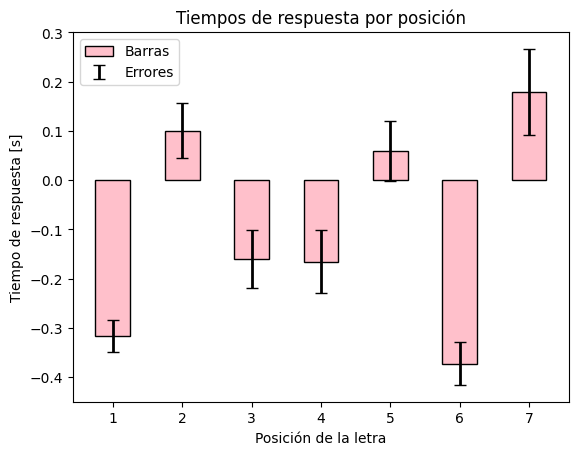

In [ ]:
#ploteo
plt.bar(x, prom_t_tot, width = 0.5, color='pink', edgecolor='black', label='Barras') #gráfico derrorbare barras
plt.xlabel('Posición de la letra')
plt.ylabel('Tiempo de respuesta [s]')
plt.errorbar(x, prom_t_tot, yerr=err_t_tot, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.title('Tiempos de respuesta por posición')
plt.show()

#sigm/SQRT(N-1)122	              ""	     34.8379	   1254.88	    0.0	    00000000     00000000	   1	[       ]
19    	0     	    222	              ""	     36.1045

#bloques que no se usan

In [ ]:
#errores
Prueba1 = np.array([1,1,1])
Prueba2 = np.array([1,1,0]) #estoy viendo que los promedios por posicion por archivo solo pueden tener desv estandar 0 o 0.15
Prueba3 = np.array([1,0,0])
Prueba4 = np.array([0,0,0])
desvest1 = np.std(Prueba1)/len(Prueba1)
desvest2 = np.std(Prueba2)
desvest3 = np.std(Prueba3)/len(Prueba3)
desvest4 = np.std(Prueba4)/len(Prueba4)
print(desvest1, desvest2, desvest3, desvest4)

0.0 0.4714045207910317 0.15713484026367722 0.0


In [ ]:
#esto ya no lo usamos
'''
porcentaje = (rtas_corr/(3*cant_archivos))*100 #vector de porcentajes
print(porcentaje) #bue me cagarooon todo ese kilombo para que los porcentajes den igual
'''

In [ ]:
'''
lista1, lista2, lista3, lista4 = [],[],[],[]
for i in range(1, 3):
    for k in range(1, 4+1):
        valor = []
        valor.clear()
        valor.append(k)
        eval(f"lista{k}").append(np.mean(valor))
        print(lista1, lista2, lista3, lista4)
    print(lista1, lista2, lista3, lista4)

lista1.append(8)
print(lista1)
'''

In [ ]:
'''
tiempo_corr = np.array([0.000000]*7) #vector donde sumamos los tiempos de las rtas correctas por posicion

tiempo_pos_1, tiempo_pos_2, tiempo_pos_3, tiempo_pos_4, tiempo_pos_5, tiempo_pos_6, tiempo_pos_7 = [],[],[],[],[],[],[]
for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            tiempo_corr[posicion[j]-1] += tiempos_en0[j] #y sumo el tiempo de rta en la posicion correspondiente
print(tiempo_corr)

tiempo_prom = tiempo_corr/rtas_corr #tiempo prom de respuesta por posicion (considerando todos los archivos juntos)
print(tiempo_prom)

for j in range(len(tiempos_en0)): #clasifico los tiempos de rta correctas segun la posicion
             if posicion[j] == 1:
                tiempo_pos_1.append(tiempos_en0[j])
             elif posicion[j] == 2:
                tiempo_pos_2.append(tiempos_en0[j])
             elif posicion[j] == 3:
                tiempo_pos_3.append(tiempos_en0[j])
             elif posicion[j] == 4:
                tiempo_pos_4.append(tiempos_en0[j])
             elif posicion[j] == 5:
                tiempo_pos_5.append(tiempos_en0[j])
             elif posicion[j] == 6:
                tiempo_pos_6.append(tiempos_en0[j])
             elif posicion[j] == 7:
                tiempo_pos_7.append(tiempos_en0[j])
            #if posicion[j] == i+1:
             #   eval(f"tiempo_pos_{i+1}").append(tiempos_en0[j])

tiempo_prom_err=[] #calculo la desviacion en cada posicion
for i in range(len(tiempo_prom)):
  tiempo_prom_err.append(np.std(eval(f"tiempo_pos_{i+1}"))/len(eval(f"tiempo_pos_{i+1}")))
  print(len(eval(f"tiempo_pos_{i+1}")))
print(tiempo_prom_err)
'''